# Week 1 — LLaVA Model Loading & First Inference

**Option A: Controllable Synthesis & Editing | MSc Dissertation — Newcastle University**

> Run `week1_data_colab.ipynb` FIRST — `test.csv` must exist before this notebook.

**Literature:**
- Liu et al. (2023) LLaVA — https://arxiv.org/abs/2304.08485
- Alayrac et al. (2022) Flamingo — https://arxiv.org/abs/2204.14198
- Radford et al. (2021) CLIP — https://arxiv.org/abs/2103.00020


In [1]:
# ── CELL 1 — Mount Google Drive ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [2]:
# ── CELL 2 — Install packages ─────────────────────────────────────────────
# Strategy: use whatever transformers Colab already has (avoids conflicts)
# Only install what is truly missing.
# NO bitsandbytes — CUDA 12.8 has no pre-built bnb library.
# Model loads in float16 which fits on T4 (15GB VRAM).

!pip install -q --upgrade accelerate
!pip install -q sentencepiece

# Check what transformers version is already installed
import subprocess, sys
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'show', 'transformers'],
    capture_output=True, text=True
)
for line in result.stdout.split('\n'):
    if line.startswith('Version'):
        print(f'transformers already installed: {line}')
        break

print('Packages ready.')
print('No restart needed — proceed directly to Cell 3.')

transformers already installed: Version: 5.0.0
Packages ready.
No restart needed — proceed directly to Cell 3.


In [3]:
# ── CELL 3 — Set paths ────────────────────────────────────────────────────
import os

BASE          = '/content/drive/MyDrive/dissertation_final'
PROCESSED_DIR = f'{BASE}/data/processed'
RESULTS_DIR   = f'{BASE}/results'
MODELS_DIR    = f'{BASE}/models'
MODEL_CACHE   = f'{MODELS_DIR}/llava_cache'
N_SAMPLES     = 10

# Model — using LLaVA-1.5 13B is too large, use 7B
MODEL_ID = 'llava-hf/llava-v1.6-mistral-7b-hf'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

test_csv = f'{PROCESSED_DIR}/test.csv'
print('Path check:')
print(f'  test.csv    : {os.path.exists(test_csv)} -> {test_csv}')
print(f'  results/    : {os.path.exists(RESULTS_DIR)}')
print(f'  model cache : {os.path.exists(MODEL_CACHE)}')

if not os.path.exists(test_csv):
    print('\nERROR: test.csv missing — run week1_data_colab.ipynb first.')
else:
    print('\nPaths OK. Proceed to Cell 4.')

Path check:
  test.csv    : True -> /content/drive/MyDrive/dissertation_final/data/processed/test.csv
  results/    : True
  model cache : False

Paths OK. Proceed to Cell 4.


In [4]:
# ── CELL 4 — Check GPU and VRAM ──────────────────────────────────────────
import torch

if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    cuda = torch.version.cuda
    print(f'GPU          : {name}')
    print(f'VRAM         : {vram:.1f} GB')
    print(f'CUDA version : {cuda}')
    print(f'torch        : {torch.__version__}')
    if vram >= 14:
        print('Status       : Sufficient VRAM for float16 LLaVA-7B.')
    elif vram >= 8:
        print('Status       : Marginal VRAM — will use aggressive memory saving.')
    else:
        print('WARNING      : Low VRAM — switch to Runtime -> T4 or A100 GPU.')
else:
    print('No GPU. Go to Runtime -> Change runtime type -> T4 GPU.')

GPU          : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM         : 102.0 GB
CUDA version : 12.8
torch        : 2.10.0+cu128
Status       : Sufficient VRAM for float16 LLaVA-7B.


In [5]:
# ── CELL 5 — Import libraries ─────────────────────────────────────────────
import os, pandas as pd, torch
from PIL import Image
from pathlib import Path

import transformers
print(f'transformers version : {transformers.__version__}')

# Import the right processor class depending on transformers version
transf_version = tuple(int(x) for x in transformers.__version__.split('.')[:2])

if transf_version >= (4, 38):
    # Newer transformers — use AutoProcessor + AutoModel
    from transformers import AutoProcessor, LlavaNextForConditionalGeneration
    USE_AUTO = True
    print('Using AutoProcessor (transformers >= 4.38)')
else:
    # Older transformers — use LlavaNextProcessor directly
    from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration
    USE_AUTO = False
    print('Using LlavaNextProcessor (transformers < 4.38)')

print('All imports done.')

transformers version : 5.0.0
Using AutoProcessor (transformers >= 4.38)
All imports done.


In [6]:
# ── CELL 6 — Load LLaVA ──────────────────────────────────────────────────
#
# Approach: float16, no bitsandbytes, auto device map
# Works on any CUDA version including 12.8
# T4 has 15GB VRAM — float16 LLaVA-7B uses ~14GB — fits

def load_llava():
    config_path = os.path.join(MODEL_CACHE, 'config.json')
    load_from   = MODEL_CACHE if os.path.exists(config_path) else MODEL_ID

    if load_from == MODEL_CACHE:
        print(f'Loading from Drive cache: {load_from}')
    else:
        print(f'Downloading from HuggingFace: {MODEL_ID}')
        print('First run — ~14GB download, takes 10-20 min...')

    # Clear GPU cache first
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        free_vram = torch.cuda.mem_get_info()[0] / 1e9
        print(f'Free VRAM before load: {free_vram:.1f} GB')

    # Load processor
    print('Loading processor...')
    if USE_AUTO:
        processor = AutoProcessor.from_pretrained(load_from)
    else:
        processor = LlavaNextProcessor.from_pretrained(
            load_from, use_fast=False
        )
    print('Processor ready.')

    # Load model — float16, no bitsandbytes
    print('Loading model in float16 (no bitsandbytes needed)...')
    model = LlavaNextForConditionalGeneration.from_pretrained(
        load_from,
        torch_dtype=torch.float16,
        device_map='auto',
        low_cpu_mem_usage=True,
    )
    model.eval()

    used_vram = (
        torch.cuda.get_device_properties(0).total_memory
        - torch.cuda.mem_get_info()[0]
    ) / 1e9 if torch.cuda.is_available() else 0

    print(f'Model loaded on : {next(model.parameters()).device}')
    print(f'Model dtype     : {next(model.parameters()).dtype}')
    print(f'VRAM used       : {used_vram:.1f} GB')
    return processor, model

processor, model = load_llava()
print('\nLLaVA ready.')

First run — ~14GB download, takes 10-20 min...
Free VRAM before load: 101.4 GB
Loading processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded on : cuda:0
Model dtype     : torch.float16
VRAM used       : 15.7 GB

LLaVA ready.


In [7]:
# ── CELL 7 — Cache model to Drive (first session only) ───────────────────
# Skip if cache already exists.

if not os.path.exists(os.path.join(MODEL_CACHE, 'config.json')):
    print(f'Caching model to Drive: {MODEL_CACHE}')
    os.makedirs(MODEL_CACHE, exist_ok=True)
    processor.save_pretrained(MODEL_CACHE)
    model.save_pretrained(MODEL_CACHE)
    size = sum(
        os.path.getsize(os.path.join(MODEL_CACHE, f))
        for f in os.listdir(MODEL_CACHE)
        if os.path.isfile(os.path.join(MODEL_CACHE, f))
    ) / 1e9
    print(f'Cached {size:.1f} GB to Drive. Future sessions load in ~30s.')
else:
    print('Model already cached in Drive. Skipping.')

Caching model to Drive: /content/drive/MyDrive/dissertation_final/models/llava_cache


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Cached 15.1 GB to Drive. Future sessions load in ~30s.


In [8]:
# ── CELL 8 — generate_caption() ──────────────────────────────────────────
# Core function — used in ALL weeks 3 to 8.
# Works with both AutoProcessor and LlavaNextProcessor.

def generate_caption(processor, model, image, prompt='Describe this image in detail.', max_new_tokens=100):
    conversation = [{
        'role': 'user',
        'content': [
            {'type': 'image'},
            {'type': 'text', 'text': prompt},
        ],
    }]
    text_input = processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs = processor(images=image, text=text_input, return_tensors='pt').to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
        )

    input_len = inputs['input_ids'].shape[1]
    caption   = processor.batch_decode(output_ids[:, input_len:], skip_special_tokens=True)[0]
    return caption.strip()

print('generate_caption() ready — used in all weeks 3-8.')

generate_caption() ready — used in all weeks 3-8.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Testing on one image...
Generated : In the heart of a gravel field, a lively game of soccer unfolds. Two players, clad in vibrant red and black jerseys, are caught in the midst of action. The player in the red jersey, positioned on the left side of the image, is in the process of kicking the ball, sending it flying towards the right side of the image. 

On the right side of the image, the player in the black jersey is seen running towards
Reference : Three people are playing with a red kick ball.


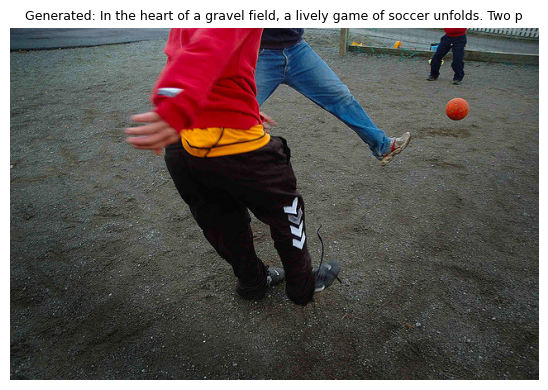

Single image test passed.


In [9]:
# ── CELL 9 — Single image test ────────────────────────────────────────────
import matplotlib.pyplot as plt

test_df  = pd.read_csv(f'{PROCESSED_DIR}/test.csv')
test_row = test_df.iloc[0]
test_img = Image.open(test_row['img_path']).convert('RGB')

print('Testing on one image...')
caption = generate_caption(processor, model, test_img)
ref     = test_row['captions'].split(' | ')[0]
print(f'Generated : {caption}')
print(f'Reference : {ref}')

fig, ax = plt.subplots(figsize=(6,4))
ax.imshow(test_img)
ax.set_title(f'Generated: {caption[:70]}', fontsize=9)
ax.axis('off')
plt.tight_layout()
plt.show()
print('Single image test passed.')

In [10]:
# ── CELL 10 — Run inference on 10 test images ─────────────────────────────
records = []
df = pd.read_csv(f'{PROCESSED_DIR}/test.csv').head(N_SAMPLES)

print('='*55)
print('Week 1 — LLaVA First Inference')
print('Literature: Liu et al. (2023); Alayrac et al. (2022)')
print('='*55)

for idx, (_, row) in enumerate(df.iterrows()):
    print(f'\n[{idx+1}/{N_SAMPLES}] {Path(row["img_path"]).name}')
    img  = Image.open(row['img_path']).convert('RGB')
    gen  = generate_caption(processor, model, img)
    refs = row['captions'].split(' | ')
    print(f'  Generated : {gen}')
    print(f'  Reference : {refs[0]}')
    records.append({
        'image_id':          row['image_id'],
        'img_path':          row['img_path'],
        'generated_caption': gen,
        'reference_1':       refs[0],
        'all_references':    row['captions'],
    })

results_df = pd.DataFrame(records)
print(f'\nDone. {len(results_df)} captions generated.')

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Week 1 — LLaVA First Inference
Literature: Liu et al. (2023); Alayrac et al. (2022)

[1/10] 000000577864.jpg
  Generated : In the heart of a gravel field, a lively game of soccer unfolds. Two players, clad in vibrant red and black jerseys, are caught in the midst of action. The player in the red jersey, positioned on the left side of the image, is in the process of kicking the ball, sending it flying towards the right side of the image. 

On the right side of the image, the player in the black jersey is seen running towards
  Reference : Three people are playing with a red kick ball.

[2/10] 000000238013.jpg


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Generated : In the heart of the image, a man is captured in the midst of an intense game of tennis. He's dressed in a crisp white t-shirt and black shorts, his body poised in anticipation of the ball. His right hand grips a tennis racket, ready to strike, while his left hand is extended, fingers splayed in a gesture of balance and control.

The man is positioned on the left side of the image, his body angled towards
  Reference : A man is playing tennis, the ball is coming toward him.

[3/10] 000000560911.jpg


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

  Generated : The image captures a serene and well-organized bathroom. Dominating the scene is a pristine white bathtub, its surface gleaming under the soft light. Adjacent to the bathtub, a white toilet stands, its lid closed. Above the bathtub, a window with a white frame allows a glimpse of the world outside. The window is adorned with white blinds, partially drawn to let in a soft light that illuminates the room
  Reference : The bathroom is white and looks very clean.

[9/10] 000000429109.jpg


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Generated : The image captures a vibrant scene at a bus station. Dominating the foreground is a white bus, adorned with a purple stripe and the words "LNEA EXPRESS" in bold red letters. This bus is in motion, driving away from the camera.

In the background, a red bus is stationary, parked at the bus stop. It's a striking contrast to the white bus in the foreground. The bus stop itself is a bustling hub
  Reference : A street filled with buses and a white van.

[10/10] 000000315492.jpg


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Generated : In the heart of a cozy bathroom, a young child is engrossed in a playful activity. The child, dressed in a vibrant red and black striped shirt, is kneeling on the floor, their attention captivated by a white plate. The plate, held securely in the child's hands, is adorned with a single brown teddy bear. The child's blonde hair is neatly tied back, allowing for a clear view of their
  Reference : A girl is playing with a teddy bear in a bathroom.

Done. 10 captions generated.


In [11]:
# ── CELL 11 — Save results to Drive ──────────────────────────────────────
out = f'{RESULTS_DIR}/week1_first_inference.csv'
results_df.to_csv(out, index=False)
print(f'Saved to: {out}')
print(results_df[['image_id','generated_caption','reference_1']].to_string(index=False))

Saved to: /content/drive/MyDrive/dissertation_final/results/week1_first_inference.csv
 image_id                                                                                                                                                                                                                                                                                                                                                                                                                         generated_caption                                                    reference_1
   577864                  In the heart of a gravel field, a lively game of soccer unfolds. Two players, clad in vibrant red and black jerseys, are caught in the midst of action. The player in the red jersey, positioned on the left side of the image, is in the process of kicking the ball, sending it flying towards the right side of the image. \n\nOn the right side of the image, the player in the black jersey is 

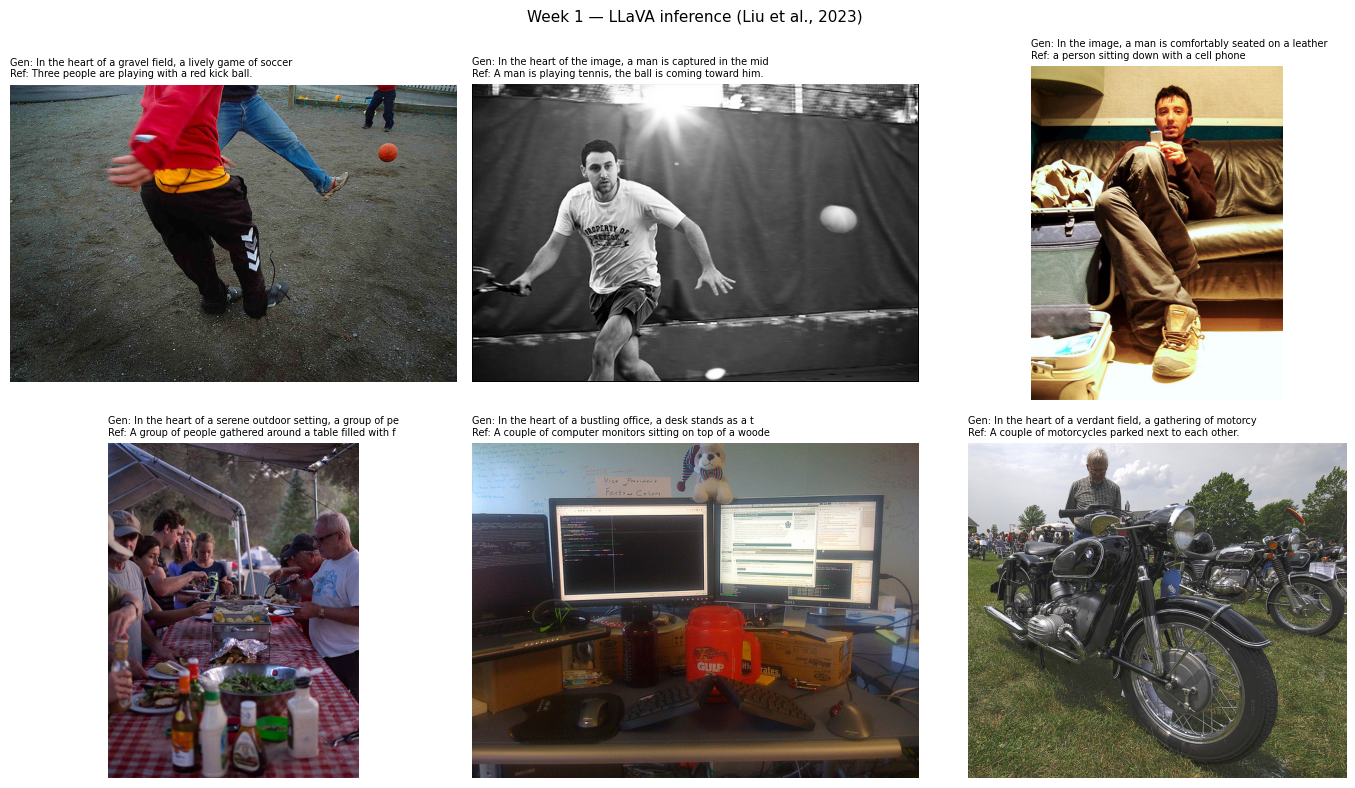

Grid saved to /content/drive/MyDrive/dissertation_final/results/week1_inference_grid.png


In [12]:
# ── CELL 12 — Show grid ───────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, (_, row) in enumerate(results_df.head(6).iterrows()):
    img = Image.open(row['img_path']).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(
        f'Gen: {row["generated_caption"][:55]}\nRef: {row["reference_1"][:55]}',
        fontsize=7, loc='left'
    )
    axes[i].axis('off')
plt.suptitle('Week 1 — LLaVA inference (Liu et al., 2023)', fontsize=11)
plt.tight_layout()
path = f'{RESULTS_DIR}/week1_inference_grid.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grid saved to {path}')

In [13]:
# ── CELL 13 — Final verification ──────────────────────────────────────────
print('='*55)
print('Week 1 — Final verification')
print('='*55)
for fpath in [
    f'{PROCESSED_DIR}/test.csv',
    f'{RESULTS_DIR}/week1_first_inference.csv',
    f'{RESULTS_DIR}/week1_inference_grid.png',
    f'{MODEL_CACHE}/config.json',
]:
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) if exists else 0
    print(f'  [{"OK" if exists else "MISSING"}] {os.path.basename(fpath):40s} {size:>10,} bytes')

print()
print('Week 1 Model complete. Next: week2_explore_colab.ipynb')

Week 1 — Final verification
  [OK] test.csv                                     38,190 bytes
  [OK] week1_first_inference.csv                     8,404 bytes
  [OK] week1_inference_grid.png                  3,148,164 bytes
  [OK] config.json                                   1,946 bytes

Week 1 Model complete. Next: week2_explore_colab.ipynb
